# Visualization of saved distance matrices


Visualize arrays saved in `\res` folder here.



In [25]:
import os
os.getcwd()

os.chdir('/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/')


In [27]:
import importlib
import numpy as np
from grid.grid_functions import *

In [28]:
# Load the files:
res_root = "grid/res/16_years/"
print(res_root + "dists_obs_16y.npy")
dists = np.load(res_root + "dists_obs_16y.npy")
pairs = np.load(res_root + "pairs_obs_16y.npy")


true_par1 = 0.0758#0.145
true_par2 = 0.013 #0.036

grid/res/16_years/dists_obs_16y.npy


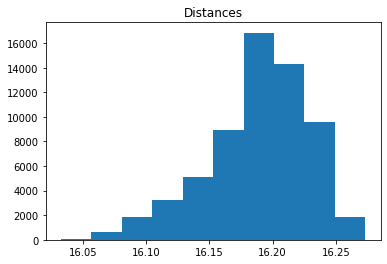

In [10]:
plt.hist(dists)
plt.title("Distances")
plt.show()

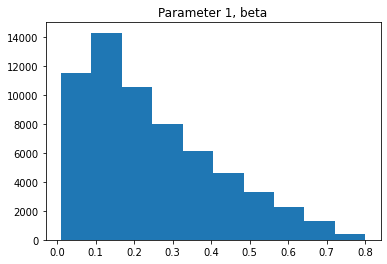

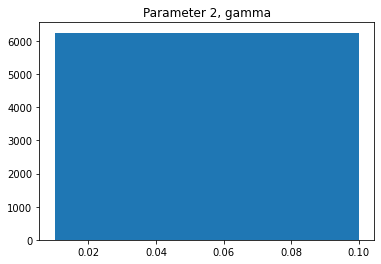

Overall mean of par1 (beta or net transmission) 0.24750027500000005
Overall mean of par2 (gamma or R) 0.05500000000000001


In [11]:
plt.hist(pairs[:,0])
plt.title("Parameter 1, beta") # or net transmission
plt.show()

plt.hist(pairs[:,1])
plt.title("Parameter 2, gamma") # or R
plt.show()

print("Overall mean of par1 (beta or net transmission)", np.mean(pairs[:,0]))
print("Overall mean of par2 (gamma or R)", np.mean(pairs[:,1]))

In [12]:
# Print point estimates:
eps =16.1
print(f"Beta mean: {np.mean(pairs[np.where(dists< eps)[0],0])}")
print(f"Gamma mean: {np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"R = beta mean/gamma mean: {np.mean(pairs[np.where(dists < eps)[0],0])/np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"True parameters (for synthetic data): beta = {true_par1}, gamma = {true_par2}")

Beta mean: 0.07586436405634066
Gamma mean: 0.013117234451781546
R = beta mean/gamma mean: 5.783563931499065
True parameters (for synthetic data): beta = 0.0758, gamma = 0.013


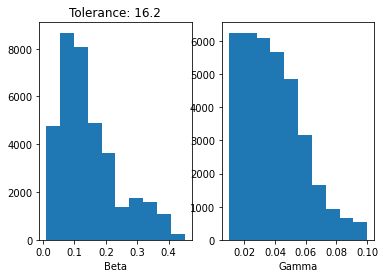

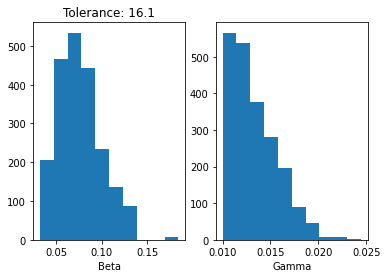

In [13]:
# Visualize:
plot_histograms(dists, pairs[:,0], pairs[:,1], 16.2, save = True, filename = res_root + "tolerance_hist_test.pdf")
plot_histograms(dists, pairs[:,0], pairs[:,1], 16.1, save = True, filename = res_root + "tolerance_hist_test.pdf")

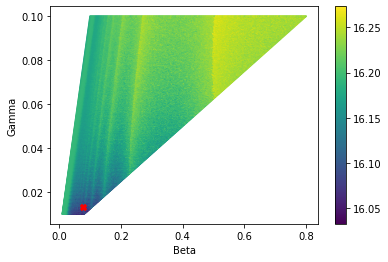

In [14]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_beta = true_par1, true_gamma = true_par2,\
                        save = True, filename = res_root + "grid_scatter_test.pdf")

Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


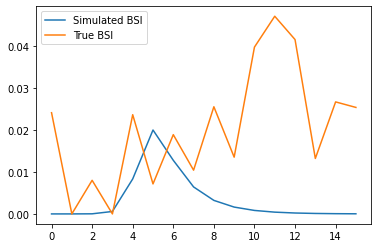

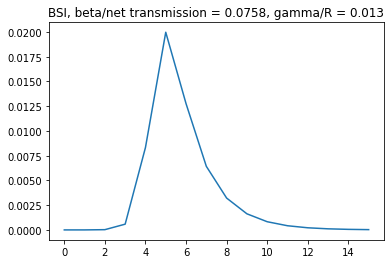

In [15]:
from cluster.scripts.load_data import *
n_weeks = 16*52
pop_size = 5000000
obs_data = "NORM"
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.001}
bsi_real_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

if obs_data == "NORM":
    bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
else:
    bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)


plt.plot(bsi_real_sim[0], label = "Simulated BSI") # jos kerron sadalla, osuu tuohon yhteen piikkiin sentään.
plt.plot(np.array(bsi_obs_data), label = "True BSI")
plt.legend()
plt.show()

plt.plot(bsi_real_sim[0])
plt.title(f"BSI, beta/net transmission = {true_par1}, gamma/R = {true_par2}")
plt.show()

### Aggregate example

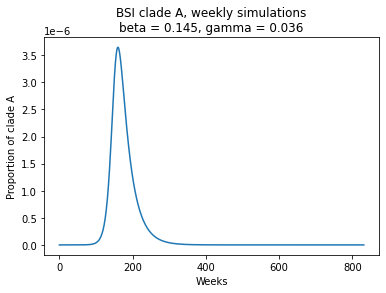

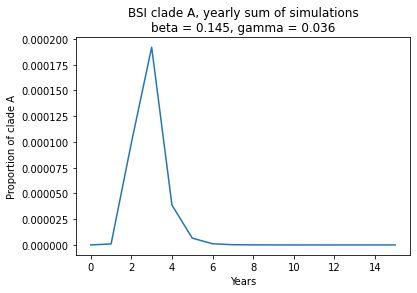

In [238]:
true_par1 = 0.145
true_par2 = 0.036



bsi_sim_agg = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)
bsi_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)



plt.plot(bsi_sim[0])
plt.title(f"BSI clade A, weekly simulations\nbeta = {true_par1}, gamma = {true_par2}")
plt.ylabel("Proportion of clade A")
plt.xlabel("Weeks")
plt.show()

plt.plot(bsi_sim_agg[0])
plt.title(f"BSI clade A, yearly sum of simulations\nbeta = {true_par1}, gamma = {true_par2}")
plt.ylabel("Proportion of clade A")
plt.xlabel("Years")
plt.show()

# Simulated aggregated data, visualizing colonisation

In [29]:
# Load the files:
#res_root = "/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/grid/res/16_years/" # or change working directory
print(res_root + "dists_synt_agg_16y.npy")
dists = np.load(res_root + "dists_synt_agg_16y.npy")
pairs = np.load(res_root + "pairs_synt_agg_16y.npy")


true_par1 = 0.145
true_par2 = 0.036 

grid/res/16_years/dists_synt_agg_16y.npy


In [33]:
# Simulator settings
from cluster.scripts.load_data import *

n_weeks = 16*52
pop_size = 5000000
obs_data = "NORM"
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.001}
bsi_real_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

if obs_data == "NORM":
    bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
else:
    bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)

Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


In [30]:
pairs.shape

n = 3
int(pairs.shape[0]/(n*n))


6944

In [35]:
pairs[100,1]

0.01

In [40]:
n_weeks

832

In [83]:
min(pairs[:,0])

0.010000100000000001

In [84]:
max(pairs[:,0])

0.8

In [86]:
(max(pairs[:,0]) - min(pairs[:,0]))/3

0.26333330000000005

0.01 0.01
0.8 0.1
0.0002811240963855443
[0.01, 0.04, 0.1]
[0.010000100000000001, 0.27333340000000006, 0.8]
(16,)
[2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
16


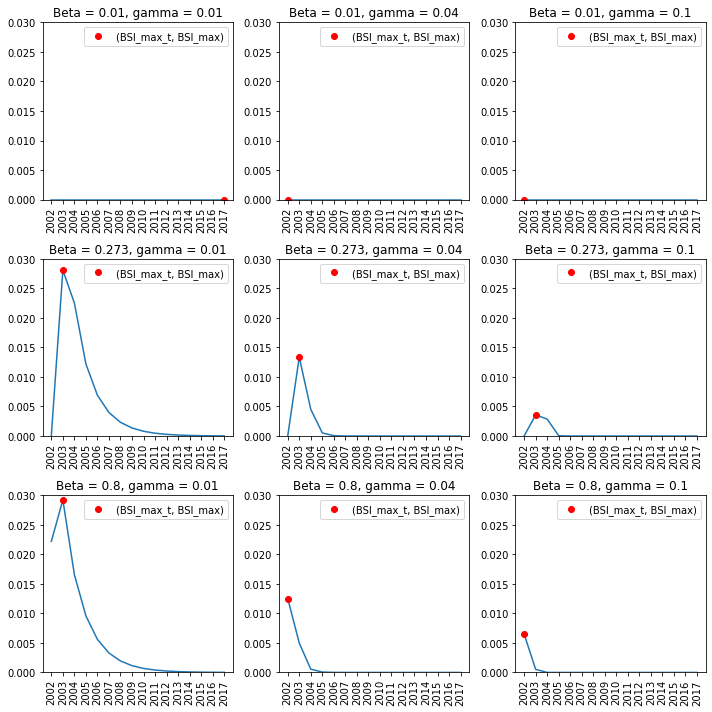

0.006482111944359789

In [97]:
# Alternative: evenly spaced parameter pairs
n = 3

inc = int(pairs.shape[0]/(n*n))

min_par1 = np.min(pairs[:,0])
min_par2 = np.min(pairs[:,1])

max_par1 = np.max(pairs[:,0])
max_par2 = np.max(pairs[:,1])

print(min_par2, min_par2)
print(max_par1, max_par2)

stepsize = pairs[3,0] - pairs[2,0]
print(stepsize)

# First, find 3 gamma values, evenly spaced:

gammas = [min(pairs[:,1]), min(pairs[:,1]) + (max(pairs[:,1]) - min(pairs[:,1]))/3, max(pairs[:,1])]
betas  = [min(pairs[:,0]), min(pairs[:,0]) + (max(pairs[:,0]) - min(pairs[:,0]))/3, max(pairs[:,0])]

print(gammas)
print(betas)

x = np.arange(0, 16)
y = []
par1s = []
par2s = []

for b in betas:
    for g in gammas:
        
        y.append(SIR_and_BSI_simulator(np.array([b]), np.array([g]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)[0])
        
        
        par1s.append(b)
        par2s.append(g)


        
print(y[1].shape)
# The following lines are a courtesy of ChatGPT :D
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

x_tick_labels = [i + 1 for i in range(2001, 2017)]
print(x_tick_labels)
print(len(x_tick_labels))

y_min = 0
y_max = 0.03

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot the line plots in each subplot
for i, ax in enumerate(axes):
    ax.plot(x, y[i])
    ax.set_title(f'Beta = {np.round(par1s[i],3)}, gamma = {np.round(par2s[i],4)}')
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation = 90)
    
    point = ax.plot(BSI_max_t(y[i]), BSI_max(y[i]), "ro",label = "(BSI_max_t, BSI_max)")[0]
    ax.legend(handles = [point], loc='upper right')

# Adjust the spacing between subplots
plt.tight_layout()

# Display the grid of line plots
plt.show()

# Also show summaries
BSI_max(y[i])

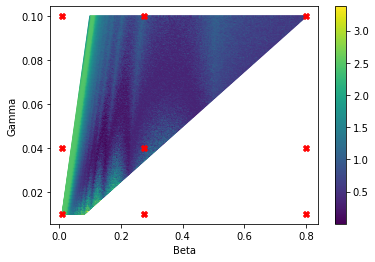

In [98]:
sc = plt.scatter(pairs[:,0], pairs[:,1], c = dists, s = 1)

for i in range(0, 9):
    plt.scatter(par1s[i], par2s[i], c= "red", marker = "X")
plt.xlabel("Beta")
plt.ylabel("Gamma")
plt.colorbar(sc)
sc.set_cmap('viridis') # 'plasma'
#sc.set_clim(cutoff_lower, cutoff_upper)

0
6944
13888
20832
27776
34720
41664
48608
55552
(16,)
[2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
16


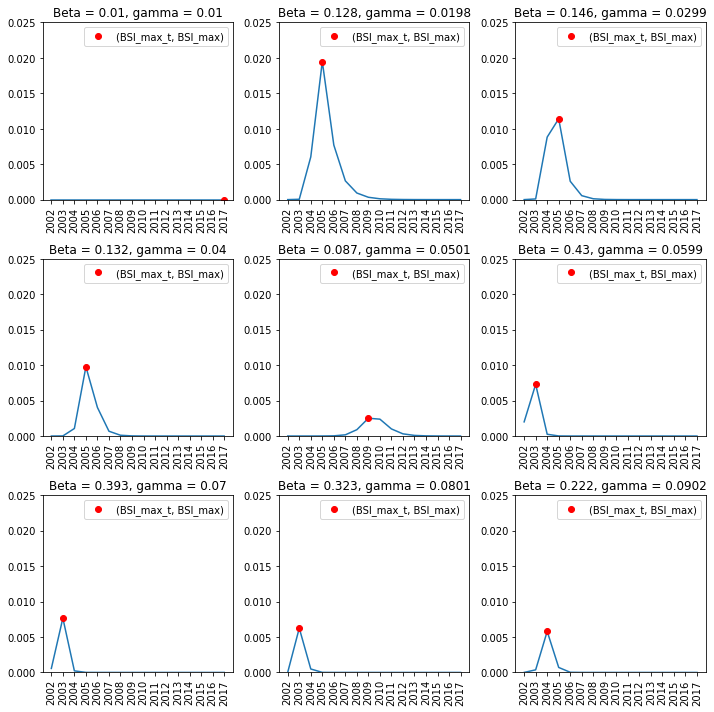

0.005786353401763159

In [82]:
# Form a 3x3 grid of colonisation figures

import matplotlib.pyplot as plt
import numpy as np

# Generate some random data for the line plots
#x = np.linspace(0, n_weeks, )
x = np.arange(0, 16)



# Find nine parameter pair examples & visualize them in a grid

y = []

n = 3

inc = int(pairs.shape[0]/(n*n))

par1s = []
par2s = []

for i in range(0,9):
    
    if i == 0:
        j = i
    else:
        j += inc
    
    if j > pairs.shape[0]:
        j = pairs.shape[0] - 1

    print(j)
        
    y.append(SIR_and_BSI_simulator(np.array([pairs[j,0]]), np.array([pairs[j,1]]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)[0])
    
    par1s.append(pairs[j,0])
    par2s.append(pairs[j,1])
    
    
print(y[1].shape)
# The following lines are a courtesy of ChatGPT :D
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

x_tick_labels = [i + 1 for i in range(2001, 2017)]
print(x_tick_labels)
print(len(x_tick_labels))

y_min = 0
y_max = 0.025

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot the line plots in each subplot
for i, ax in enumerate(axes):
    ax.plot(x, y[i])
    ax.set_title(f'Beta = {np.round(par1s[i],3)}, gamma = {np.round(par2s[i],4)}')
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation = 90)
    
    point = ax.plot(BSI_max_t(y[i]), BSI_max(y[i]), "ro",label = "(BSI_max_t, BSI_max)")[0]
    ax.legend(handles = [point], loc='upper right')

# Adjust the spacing between subplots
plt.tight_layout()

# Display the grid of line plots
plt.show()

# Also show summaries
BSI_max(y[i])

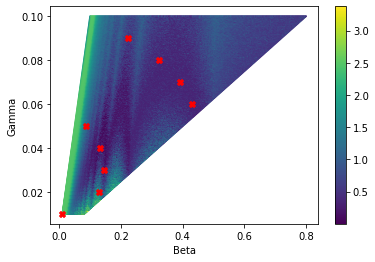

In [46]:
sc = plt.scatter(pairs[:,0], pairs[:,1], c = dists, s = 1)

for i in range(0, 9):
    plt.scatter(par1s[i], par2s[i], c= "red", marker = "X")
plt.xlabel("Beta")
plt.ylabel("Gamma")
plt.colorbar(sc)
sc.set_cmap('viridis') # 'plasma'
#sc.set_clim(cutoff_lower, cutoff_upper)